In [1]:
import sys
import os
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

In [2]:
from utils.dataloader import get_dataloader, get_transforms

BASE_DIR = os.path.abspath("..")

train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

train_transform, val_transform = get_transforms()

train_loader, train_dataset = get_dataloader(
    train_path,
    transform=train_transform,
    use_weighted_sampler=True
)

val_loader, val_dataset = get_dataloader(
    val_path,
    transform=val_transform,
    use_weighted_sampler=False
)

test_loader, test_dataset = get_dataloader(
    test_path,
    transform=val_transform,
    use_weighted_sampler=False
)

Class counts: [34 14 32 35 23 30 34 28 13 35 27 32 34 12 21 28 24 29 32 28 25 22 31 14
 35 33 30 26 35 33 32 32]


In [3]:
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

log_dir = os.path.join(BASE_DIR, "outputs/logs/mobile_net", f"run_{timestamp}")
os.makedirs(log_dir, exist_ok=True)

writer = SummaryWriter(log_dir)

In [4]:
log_file = os.path.join(log_dir, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

In [5]:
from models.mobile_net import MobileNetTransformer

NUM_CLASSES = len(train_loader.dataset.label_map)

model = MobileNetTransformer(num_classes=NUM_CLASSES)

In [6]:
import torch
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for param in model.encoder.features[:-4].parameters():
    param.requires_grad = False

for param in model.encoder.features[-4:].parameters():
    param.requires_grad = True

In [7]:
import torch
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # (B,)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# ===== LOSS FUNCTION =====
criterion = FocalLoss(gamma=2)

In [8]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

In [9]:
EPOCHS = 50
patience = 3
counter = 0
best_val_loss = float("inf")

import json

config = {
    "model": "MobileNetTransformer",
    "epochs": 50,
    "lr": 3e-5,
    "weight_decay": 1e-5,
    "batch_size": train_loader.batch_size,
    "num_classes": NUM_CLASSES,
    "transformer_layers": 2
}

with open(os.path.join(log_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for x, y in train_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in val_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

            # update progress bar
            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ===== LOGGING =====
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("LR", current_lr, epoch)

    for name, param in model.named_parameters():
        writer.add_histogram(f"Weights/{name}", param, epoch)

        if param.grad is not None:
            writer.add_histogram(f"Gradients/{name}", param.grad, epoch)

    log_message(f"Epoch {epoch+1}/{EPOCHS}")
    log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    log_message(f"LR: {current_lr}")
    log_message("-" * 40)

    # ===== SCHEDULER =====
    scheduler.step(val_loss)


    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        log_message("Best model saved!")

    else:
        counter += 1
        log_message(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            log_message("Early stopping triggered!")
            break


# SAVE LAST MODEL
torch.save(model.state_dict(), os.path.join(log_dir, "last_model.pth"))


Epoch 1/50


Epoch 1/50
Train Loss: 3.3083 | Acc: 0.0246
Val   Loss: 3.2939 | Acc: 0.0385
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 2/50


Epoch 2/50
Train Loss: 3.2193 | Acc: 0.0493
Val   Loss: 2.9954 | Acc: 0.0879
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 3/50


Epoch 3/50
Train Loss: 2.9918 | Acc: 0.0952
Val   Loss: 2.7024 | Acc: 0.0989
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 4/50


Epoch 4/50
Train Loss: 2.6764 | Acc: 0.1389
Val   Loss: 2.1631 | Acc: 0.1978
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 5/50


...

Epoch 18/50
Train Loss: 0.5518 | Acc: 0.6719
Val   Loss: 0.3424 | Acc: 0.7692
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 19/50


Epoch 19/50
Train Loss: 0.4980 | Acc: 0.7032
Val   Loss: 0.2847 | Acc: 0.8022
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 20/50


Epoch 20/50
Train Loss: 0.4730 | Acc: 0.7133
Val   Loss: 0.3193 | Acc: 0.8462
LR: 0.0001
----------------------------------------
EarlyStopping counter: 1/3

Epoch 21/50


Epoch 21/50
Train Loss: 0.4976 | Acc: 0.7088
Val   Loss: 0.3735 | Acc: 0.7582
LR: 0.0001
----------------------------------------
EarlyStopping counter: 2/3

Epoch 22/50


Epoch 22/50
Train Loss: 0.4028 | Acc: 0.7581
Val   Loss: 0.3445 | Acc: 0.7582
LR: 0.0001
----------------------------------------
EarlyStopping counter: 3/3
Early stopping triggered!


In [10]:
import os
from utils.evaluate import evaluate

report_path = os.path.join(log_dir, "evaluation.json")

metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=report_path,
    model_name="MobileNetTransformer"
)

Evaluation Metrics:
accuracy: 0.7803
precision: 0.7862
recall: 0.7591
f1: 0.7500
hamming_loss: 0.2197
Experiment logged to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/metrics\experiments.csv


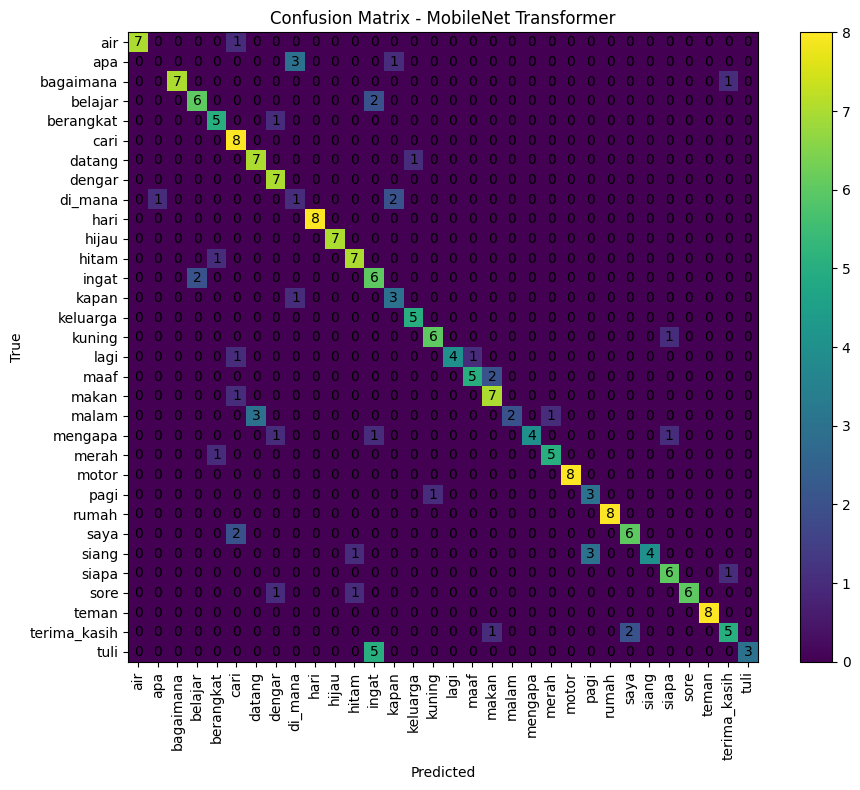

Confusion matrix saved to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/logs/mobile_net\run_20260415_191345\confusion_matrix.png


In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - MobileNet Transformer")
plt.colorbar()

labels = list(train_loader.dataset.label_map.keys())

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")

# Tambahin angka di tiap cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()

# save
cm_path = os.path.join(log_dir, "confusion_matrix.png")
plt.savefig(cm_path)

plt.show()

print("Confusion matrix saved to:", cm_path)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

from collections import Counter

print("Predicted distribution:", Counter(y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.00      0.00      0.00         4
           2       1.00      0.88      0.93         8
           3       0.75      0.75      0.75         8
           4       0.71      0.83      0.77         6
           5       0.62      1.00      0.76         8
           6       0.70      0.88      0.78         8
           7       0.70      1.00      0.82         7
           8       0.20      0.25      0.22         4
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         7
          11       0.78      0.88      0.82         8
          12       0.43      0.75      0.55         8
          13       0.50      0.75      0.60         4
          14       0.83      1.00      0.91         5
          15       0.86      0.86      0.86         7
          16       1.00      0.67      0.80         6
          17       0.83    

In [13]:
print("True count:", Counter(y_true))
print("Pred count:", Counter(y_pred))

True count: Counter({np.int64(28): 8, np.int64(9): 8, np.int64(29): 8, np.int64(26): 8, np.int64(0): 8, np.int64(2): 8, np.int64(30): 8, np.int64(5): 8, np.int64(24): 8, np.int64(6): 8, np.int64(25): 8, np.int64(11): 8, np.int64(12): 8, np.int64(18): 8, np.int64(31): 8, np.int64(22): 8, np.int64(3): 8, np.int64(20): 7, np.int64(27): 7, np.int64(10): 7, np.int64(15): 7, np.int64(17): 7, np.int64(7): 7, np.int64(16): 6, np.int64(4): 6, np.int64(19): 6, np.int64(21): 6, np.int64(14): 5, np.int64(23): 4, np.int64(8): 4, np.int64(13): 4, np.int64(1): 4})
Pred count: Counter({np.int64(12): 14, np.int64(5): 13, np.int64(7): 10, np.int64(6): 10, np.int64(18): 10, np.int64(11): 9, np.int64(9): 8, np.int64(27): 8, np.int64(29): 8, np.int64(24): 8, np.int64(3): 8, np.int64(25): 8, np.int64(22): 8, np.int64(0): 7, np.int64(2): 7, np.int64(10): 7, np.int64(15): 7, np.int64(30): 7, np.int64(4): 7, np.int64(28): 6, np.int64(23): 6, np.int64(17): 6, np.int64(21): 6, np.int64(14): 6, np.int64(13): 6, n

In [ ]:
writer.flush()
writer.close()